In [1]:
# Import Statements

import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

import os
import shutil
import pathlib
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import tensorflow as tf
from tensorflow import keras
from keras import metrics



In [2]:
# import data

path = '/Users/brentarakaki/Desktop/Berkeley/Classes/DATASCI 207 - ML/data/DeepFashion/'

category_lookup = pd.read_csv(path + 'Anno_fine/list_category_cloth.txt', 
                             sep=r'\s+',
                             header=1)

category_lookup['category_number'] = np.arange(1,51)

def create_img_df(dataset):
    valid_dataset = ['train', 'val', 'test']

    if str.lower(dataset) in valid_dataset:
        dfpath = path + 'Anno_fine/' + str.lower(dataset)
        img = pd.read_csv(dfpath+ '.txt',
                                sep=' ',
                                header=None)

        category = pd.read_csv(dfpath + '_cate.txt', 
                                     sep=r'\s+',
                                     header=None)

        img['category'] = category

        img_df = img.merge(category_lookup, left_on= 'category', right_on='category_number', how='left')[[0, 'category_type']]

        return img_df
    else:
        raise TypeError("not valid dataset type. Must pick train, val or test")



In [3]:
train_df    = create_img_df('train')
val_df      = create_img_df('val')
test_df     = create_img_df('test')

In [4]:
IMG_SIZE = (224, 224)

def load_data(dataframe):
    '''Load 2D images and their corresponding labels
    Parameters:
    dataframe (str): This is the type of data we are interested
    
    Returns:
    images (np.ndarray): A numpy array of shape (N, 224, 224, 3)
    labels (np.ndarray): A numpy array of shape (N)
    
    '''
    ## load images and labels
    images_list = []
    labels_list = []

    for i in np.arange(len(dataframe)):
        imgpath = os.path.join(path, dataframe[0][i])
        img = tf.io.read_file(imgpath)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img /= 255.0
        images_list.append(img)
        labels_list.append(dataframe['category_type'][i])

    images = np.array(images_list)
    labels = np.array(labels_list)

    return images, labels

In [5]:
train_images, train_labels = load_data(train_df)


In [6]:
print(f"""Image Shape: {train_images.shape}
Label shape: {train_labels.shape}""")

Image Shape: (14000, 224, 224, 3)
Label shape: (14000,)


In [7]:
val_images, val_labels = load_data(val_df)


In [8]:
print(f"""Image Shape: {val_images.shape}
Label shape: {val_labels.shape}""")

Image Shape: (2000, 224, 224, 3)
Label shape: (2000,)


In [9]:
test_images, test_labels = load_data(test_df)

In [10]:
print(f"""Image Shape: {test_images.shape}
Label shape: {test_labels.shape}""")

Image Shape: (4000, 224, 224, 3)
Label shape: (4000,)


In [12]:
def data_preprocessing(X, y):
    '''Apply transformations and augmentations to training, validation, and test data;
    
    Parameters:
    X  (np.ndarray): Images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)   
    data_partition (str): "train"
    
    Returns:
    X (np.ndarray): Preprocessed images of shape (N, 64, 64, 3)
    y (np.ndarray): Labels of shape (N,)
    
    '''

    X_augm = tf.image.random_flip_left_right(X) # FILL IN CODE HERE #

    # concatenate original X and augmented X_aug data
    X = tf.concat([X, X_augm], axis = 0) # FILL IN CODE HERE #

    # concatenate y_train (note the label is preserved)
    y_augm = y
    y = tf.concat([y, y_augm],axis=0)

    # shuffle X and y, i.e., shuffle two tensors in the same order
    shuffle = tf.random.shuffle(tf.range(tf.shape(X)[0], dtype=tf.int32))
    X = tf.gather(X, shuffle).numpy() # transform X back to numpy array instead of tensor
    y = tf.gather(y, shuffle).numpy() # transform y back to numpy array instead of tensor
        
        
    # rescale image by dividing each pixel by 255.0 
    # FILL IN CODE HERE #
    
    return X, y

In [11]:
features_shape = train_images[:, :, :, 0].shape[1] * train_images.shape[2] * train_images.shape[3]
train_images_re = train_images.reshape(train_images.shape[0], features_shape)
val_images_re = val_images.reshape(val_images.shape[0], features_shape)
test_images_re = test_images.reshape(test_images.shape[0], features_shape)

In [12]:
forest = RandomForestClassifier(n_estimators= 2,
                                n_jobs=1,
                                random_state=7,
                                max_depth=8)

clf_forest = forest.fit(train_images_re, train_labels)

print ('Accuracy on training data:', clf_forest.score(train_images_re, train_labels))
print ('Accuracy on validation data:', clf_forest.score(val_images_re, val_labels))

Accuracy on training data: 0.6933571428571429
Accuracy on validation data: 0.609


Text(0.5, 1.0, 'Confusion Matrix')

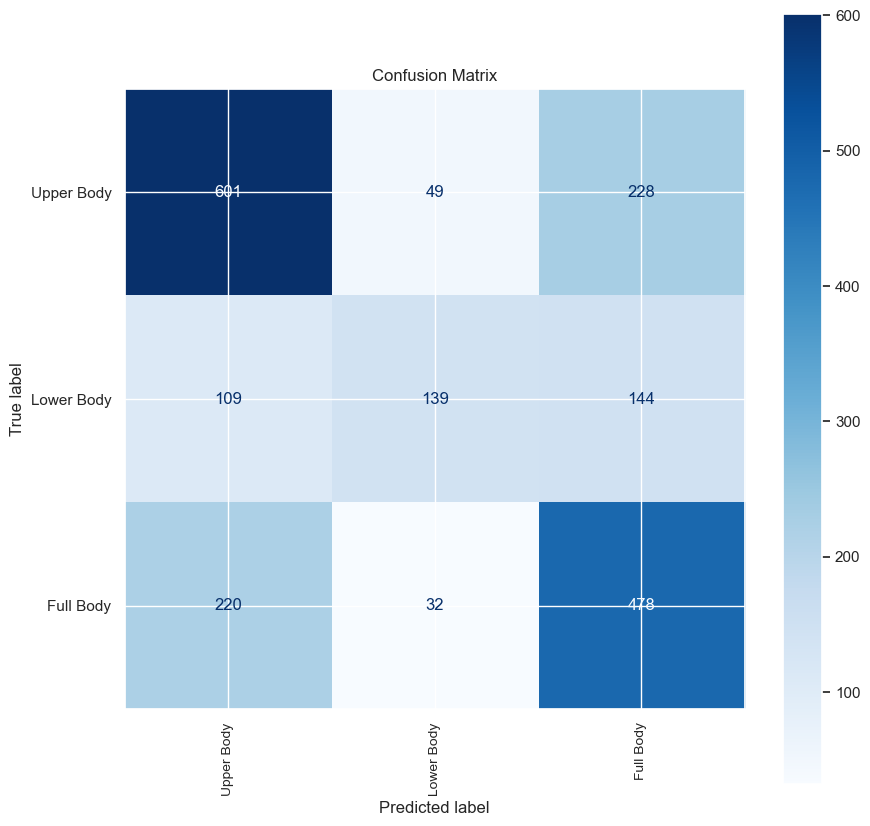

In [13]:
y_val_pred = forest.predict(val_images_re)

cm = confusion_matrix(val_labels, y_val_pred)

cmp = ConfusionMatrixDisplay(cm, 
                             display_labels=['Upper Body',
                                            'Lower Body',
                                            'Full Body'])

fig, ax = plt.subplots(figsize=(10,10))
cmp.plot(ax=ax, cmap= 'Blues')
ax.tick_params(axis='x', rotation=90, labelsize=10)
ax.set_title("Confusion Matrix")

In [14]:
print ('Accuracy on test data:', forest.score(test_images_re, test_labels))

Accuracy on test data: 0.60125
